# Import library & Data Preparation

In [2]:
!pip install lightgbm scikit-learn

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
import joblib
import os
import json
from datetime import datetime

warnings.filterwarnings("ignore")

In [4]:
# Visualisasi
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [5]:
DATA_PATH = "/kaggle/input/datasets/muhammadrafifdanuja/final-sentimen/ulasan_ovo_preprocessed_optimized.csv"
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("  DATA LOADING")
print("=" * 60)
print(f"Total baris      : {len(df):,}")
print(f"Kolom tersedia   : {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum().to_string()}")

  DATA LOADING
Total baris      : 18,997
Kolom tersedia   : ['reviewId', 'content', 'label_final', 'text_cleaned', 'tokens', 'tokens_with_negation', 'tokens_stemmed']

Missing values:
reviewId                0
content                 0
label_final             0
text_cleaned            0
tokens                  0
tokens_with_negation    0
tokens_stemmed          0


In [6]:
# Distribusi label
print("\nDistribusi Label (SEBELUM SMOTE):")
label_counts = df['label_final'].value_counts()
label_pct = df['label_final'].value_counts(normalize=True) * 100
label_summary = pd.DataFrame({'Jumlah': label_counts, 'Persentase (%)': label_pct.round(2)})
print(label_summary)


Distribusi Label (SEBELUM SMOTE):
             Jumlah  Persentase (%)
label_final                        
Negatif       14154           74.51
Positif        3055           16.08
Netral         1788            9.41


In [7]:
# Preprocess text
df['text_for_model'] = df['tokens_with_negation'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)

# Encode label
le = LabelEncoder()
y = le.fit_transform(df["label_final"])
X = df["text_for_model"].values

print(f"\nPemetaan label   : {dict(zip(le.classes_, le.transform(le.classes_)))}")


Pemetaan label   : {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}


# Data Splitting

In [8]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining  : {len(X_train):,} baris ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test      : {len(X_test):,} baris ({len(X_test)/len(X)*100:.1f}%)")


Training  : 15,197 baris (80.0%)
Test      : 3,800 baris (20.0%)


In [29]:
print("\nDistribusi label — training")
train_dist = pd.Series(y_train).value_counts().sort_index()
for i, count in train_dist.items():
    print(f"  {le.classes_[i]}: {count:,} ({count/len(y_train)*100:.1f}%)")


Distribusi label — training
  Negatif: 11,323 (74.5%)
  Netral: 1,430 (9.4%)
  Positif: 2,444 (16.1%)


# Feature Extravtion

Dalam penelitian ini, teknik Bag of Words (BoW) digunakan untuk merepresentasikan teks menjadi fitur numerik berdasarkan frekuensi kemunculan kata. Fitur dibatasi hingga 5.000 token paling sering muncul (max_features=5000) dengan kombinasi unigram dan bigram untuk menangkap konteks sederhana antar kata. Selain itu, dilakukan penyaringan kata yang terlalu jarang (min_df=2) dan terlalu umum (max_df=0.95) agar fitur lebih relevan. Parameter binary=False digunakan sehingga nilai fitur merepresentasikan frekuensi asli kemunculan kata, bukan sekadar keberadaan. Proses fit hanya dilakukan pada data latih untuk menghindari data leakage, kemudian data uji ditransformasikan menggunakan model yang sama.

In [9]:
# --- BoW untuk MLP dan LGBM ---
print("\n[1] Bag-of-Words (untuk MLP & LGBM)")
bow = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    binary=False
)
X_train_bow = bow.fit_transform(X_train).astype(np.float32)
X_test_bow = bow.transform(X_test).astype(np.float32)

print(f"\nBoW - Train shape: {X_train_bow.shape}, Test shape: {X_test_bow.shape}")


[1] Bag-of-Words (untuk MLP & LGBM)

BoW - Train shape: (15197, 5000), Test shape: (3800, 5000)


Dalam penelitian ini, teknik TF-IDF digunakan untuk mengubah teks menjadi fitur numerik dengan mempertimbangkan pentingnya kata berdasarkan frekuensinya dalam dokumen dan kelangkaannya di seluruh korpus. Fitur dibatasi hingga 5.000 token dengan kombinasi unigram dan bigram, serta dilakukan penyaringan kata yang terlalu jarang (min_df=2) dan terlalu umum (max_df=0.95) agar lebih relevan. Selain itu, digunakan skala logaritmik pada frekuensi kata untuk meningkatkan stabilitas, dan proses fit hanya dilakukan pada data latih guna menghindari data leakage.

In [11]:
# --- TF-IDF untuk SVM ---
print("\n[2] TF-IDF (untuk SVM)")
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    use_idf=True,
    smooth_idf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF - Train shape: {X_train_tfidf.shape}, Test shape: {X_test_tfidf.shape}")


[2] TF-IDF (untuk SVM)
TF-IDF - Train shape: (15197, 5000), Test shape: (3800, 5000)


# Fungsi Evaluasi

In [33]:
def evaluate_model(model, X_test, y_test, model_name: str, X_train=None, y_train=None) -> dict:
    """Evaluasi model - tampilkan Accuracy Training & Test, F1 Score"""
    # Evaluasi training (jika data training diberikan)
    train_accuracy = None
    if X_train is not None and y_train is not None:
        y_train_pred = model.predict(X_train)
        train_accuracy = accuracy_score(y_train, y_train_pred)
    
    # Evaluasi test
    y_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    print(f"\n{'─'*45}")
    print(f"  {model_name}")
    print(f"{'─'*45}")
    if train_accuracy is not None:
        print(f"  Train Acc : {train_accuracy:.4f}  ({train_accuracy*100:.2f}%)")
    print(f"  Test Acc  : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
    print(f"  F1-Score  : {f1:.4f}  (weighted)")
    
    return {
        "name": model_name,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "f1": f1,
        "y_pred": y_pred,
        "y_prob": model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    }

def tune_threshold_for_accuracy(y_test, y_prob, model_name: str, model=None, X_train=None, y_train=None, n_steps=50) -> dict:
    """
    Tuning threshold per kelas yang diOPTIMASI untuk ACCURACY.
    Bukan F1-Score.
    """
    if y_prob is None:
        return None
        
    thresholds = np.linspace(0.05, 0.95, n_steps)
    n_classes = y_prob.shape[1]
    best_thresh = [0.5] * n_classes
    
    print(f"\n{'='*50}")
    print(f"  THRESHOLD TUNING (optimasi ACCURACY): {model_name}")
    print(f"{'='*50}")
    
    for cls_idx in range(n_classes):
        best_acc = 0.0
        best_t = 0.5
        
        for t in thresholds:
            trial_thresh = best_thresh.copy()
            trial_thresh[cls_idx] = t
            
            # Apply threshold dan evaluasi accuracy
            y_pred_trial = apply_threshold(y_prob, trial_thresh)
            acc_trial = accuracy_score(y_test, y_pred_trial)
            
            if acc_trial > best_acc:
                best_acc = acc_trial
                best_t = t
        
        best_thresh[cls_idx] = best_t
        print(f"  Kelas '{le.classes_[cls_idx]:<12}' → threshold = {best_t:.2f}  (acc = {best_acc:.4f})")
    
    # Prediksi final dengan threshold optimal
    y_pred_tuned = apply_threshold(y_prob, best_thresh)
    test_accuracy = accuracy_score(y_test, y_pred_tuned)
    f1 = f1_score(y_test, y_pred_tuned, average="weighted")
    
    # Hitung training accuracy jika model dan data training diberikan
    train_accuracy = None
    if model is not None and X_train is not None and y_train is not None:
        y_train_prob = model.predict_proba(X_train)
        y_train_tuned = apply_threshold(y_train_prob, best_thresh)
        train_accuracy = accuracy_score(y_train, y_train_tuned)
    
    print(f"\n  HASIL SETELAH TUNING (optimasi accuracy):")
    if train_accuracy is not None:
        print(f"  Train Acc : {train_accuracy:.4f}  ({train_accuracy*100:.2f}%)")
    print(f"  Test Acc  : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
    print(f"  F1-Score  : {f1:.4f}")
    
    return {
        "name": model_name,
        "optimal_thresholds": {le.classes_[i]: round(best_thresh[i], 2) for i in range(n_classes)},
        "y_pred_tuned": y_pred_tuned,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "f1": f1
    }


def apply_threshold(y_prob: np.ndarray, thresholds: list) -> np.ndarray:
    """Terapkan threshold per kelas ke matriks probabilitas"""
    thresh_arr = np.array(thresholds)
    mask = y_prob >= thresh_arr
    masked_prob = y_prob.copy()
    no_class_above_thresh = ~mask.any(axis=1)
    masked_prob[~mask] = -np.inf
    masked_prob[no_class_above_thresh] = y_prob[no_class_above_thresh]
    return np.argmax(masked_prob, axis=1)

def plot_confusion_matrix(y_test, y_pred, model_name: str, classes):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()


In [34]:
results = []

# Skema pelatihan 1 : MLP+BOW

In [14]:
print("\n" + "="*60)
print("  MODEL 1: MLP + Bag-of-Words")
print("="*60)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=256,
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=False
)

print("Training MLP...")
mlp_model.fit(X_train_bow, y_train)


  MODEL 1: MLP + Bag-of-Words
Training MLP...


MLPClassifier(batch_size=256, early_stopping=True,
              hidden_layer_sizes=(128, 64, 32), learning_rate='adaptive',
              random_state=42)

In [35]:
# Evaluasi
mlp_default = evaluate_model(mlp_model, X_test_bow, y_test, "MLP + BoW (default)", X_train_bow, y_train)
mlp_tuned = tune_threshold_for_accuracy(y_test, mlp_default["y_prob"], "MLP + BoW", mlp_model, X_train_bow, y_train)


─────────────────────────────────────────────
  MLP + BoW (default)
─────────────────────────────────────────────
  Train Acc : 0.9208  (92.08%)
  Test Acc  : 0.8726  (87.26%)
  F1-Score  : 0.8517  (weighted)

  THRESHOLD TUNING (optimasi ACCURACY): MLP + BoW
  Kelas 'Negatif     ' → threshold = 0.23  (acc = 0.8753)
  Kelas 'Netral      ' → threshold = 0.58  (acc = 0.8768)
  Kelas 'Positif     ' → threshold = 0.55  (acc = 0.8768)

  HASIL SETELAH TUNING (optimasi accuracy):
  Train Acc : 0.9075  (90.75%)
  Test Acc  : 0.8768  (87.68%)
  F1-Score  : 0.8457


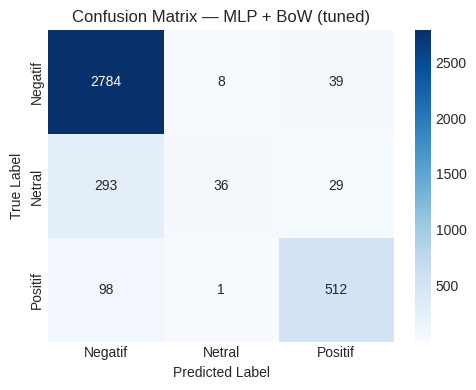

In [16]:
# Visualisasi
plot_confusion_matrix(y_test, mlp_tuned["y_pred_tuned"], "MLP + BoW (tuned)", le.classes_)

results.append({
    "Model": "MLP + BoW",
    "Acc (default)": mlp_default["accuracy"],
    "F1 (default)": mlp_default["f1"],
    "Acc (tuned)": mlp_tuned["accuracy"],
    "F1 (tuned)": mlp_tuned["f1"],
    "Thresholds": mlp_tuned["optimal_thresholds"]
})

# Skema Pelatihan 2 : LGBM + BOW

In [18]:
print("\n" + "="*60)
print("  MODEL 2: LightGBM + Bag-of-Words")
print("="*60)

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=15,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("Training LightGBM...")
lgb_model.fit(X_train_bow, y_train)


  MODEL 2: LightGBM + Bag-of-Words
Training LightGBM...


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=15,
               n_estimators=300, n_jobs=-1, random_state=42, reg_alpha=0.1,
               reg_lambda=0.1, subsample=0.8, verbose=-1)

In [36]:
lgb_default = evaluate_model(lgb_model, X_test_bow, y_test, "LightGBM + BoW (default)", X_train_bow, y_train)
lgb_tuned = tune_threshold_for_accuracy(y_test, lgb_default["y_prob"], "LightGBM + BoW", lgb_model, X_train_bow, y_train)


─────────────────────────────────────────────
  LightGBM + BoW (default)
─────────────────────────────────────────────
  Train Acc : 0.8853  (88.53%)
  Test Acc  : 0.8658  (86.58%)
  F1-Score  : 0.8328  (weighted)

  THRESHOLD TUNING (optimasi ACCURACY): LightGBM + BoW
  Kelas 'Negatif     ' → threshold = 0.49  (acc = 0.8658)
  Kelas 'Netral      ' → threshold = 0.42  (acc = 0.8663)
  Kelas 'Positif     ' → threshold = 0.27  (acc = 0.8671)

  HASIL SETELAH TUNING (optimasi accuracy):
  Train Acc : 0.8860  (88.60%)
  Test Acc  : 0.8671  (86.71%)
  F1-Score  : 0.8348


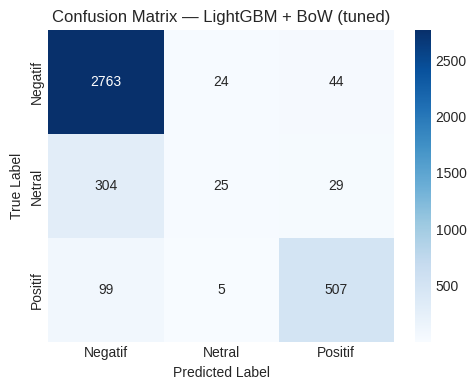

In [20]:
plot_confusion_matrix(y_test, lgb_tuned["y_pred_tuned"], "LightGBM + BoW (tuned)", le.classes_)

results.append({
    "Model": "LightGBM + BoW",
    "Acc (default)": lgb_default["accuracy"],
    "F1 (default)": lgb_default["f1"],
    "Acc (tuned)": lgb_tuned["accuracy"],
    "F1 (tuned)": lgb_tuned["f1"],
    "Thresholds": lgb_tuned["optimal_thresholds"]
})

# Skema Pelatihan 3 : SVM + TF-IDF

In [17]:
# Scaling untuk SVM
scaler_svm = StandardScaler(with_mean=False)
X_train_svm_scaled = scaler_svm.fit_transform(X_train_tfidf)
X_test_svm_scaled = scaler_svm.transform(X_test_tfidf)

In [22]:
print("\n" + "="*60)
print("  MODEL 3: SVM + TF-IDF")
print("="*60)

svm_model = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    probability=True,
    random_state=42,
    cache_size=1000
)

print("Training SVM...")
svm_model.fit(X_train_svm_scaled, y_train)


  MODEL 3: SVM + TF-IDF
Training SVM...


SVC(cache_size=1000, probability=True, random_state=42)

In [37]:
svm_default = evaluate_model(svm_model, X_test_svm_scaled, y_test, "SVM + TF-IDF (default)", X_train_svm_scaled, y_train)
svm_tuned = tune_threshold_for_accuracy(y_test, svm_default["y_prob"], "SVM + TF-IDF", svm_model, X_train_svm_scaled, y_train)


─────────────────────────────────────────────
  SVM + TF-IDF (default)
─────────────────────────────────────────────
  Train Acc : 0.9036  (90.36%)
  Test Acc  : 0.8613  (86.13%)
  F1-Score  : 0.8255  (weighted)

  THRESHOLD TUNING (optimasi ACCURACY): SVM + TF-IDF
  Kelas 'Negatif     ' → threshold = 0.45  (acc = 0.8603)
  Kelas 'Netral      ' → threshold = 0.51  (acc = 0.8603)
  Kelas 'Positif     ' → threshold = 0.18  (acc = 0.8611)

  HASIL SETELAH TUNING (optimasi accuracy):
  Train Acc : 0.9229  (92.29%)
  Test Acc  : 0.8611  (86.11%)
  F1-Score  : 0.8284


In [24]:
results.append({
    "Model": "SVM + TF-IDF",
    "Acc (default)": svm_default["accuracy"],
    "F1 (default)": svm_default["f1"],
    "Acc (tuned)": svm_tuned["accuracy"],
    "F1 (tuned)": svm_tuned["f1"],
    "Thresholds": svm_tuned["optimal_thresholds"]
})

# Perbandingan model

In [25]:
print("\n" + "="*60)
print("  RINGKASAN PERBANDINGAN MODEL")
print("="*60)

summary_df = pd.DataFrame(results).set_index("Model")
print("\n", summary_df[["Acc (default)", "F1 (default)", "Acc (tuned)", "F1 (tuned)"]].round(4))

print("\n" + "-"*50)
print("Threshold Optimal per Model (optimasi accuracy):")
for r in results:
    print(f"  {r['Model']:<18} → {r['Thresholds']}")


  RINGKASAN PERBANDINGAN MODEL

                 Acc (default)  F1 (default)  Acc (tuned)  F1 (tuned)
Model                                                               
MLP + BoW              0.8726        0.8517       0.8768      0.8457
LightGBM + BoW         0.8658        0.8328       0.8671      0.8348
SVM + TF-IDF           0.8613        0.8255       0.8611      0.8284

--------------------------------------------------
Threshold Optimal per Model (optimasi accuracy):
  MLP + BoW          → {'Negatif': np.float64(0.23), 'Netral': np.float64(0.58), 'Positif': np.float64(0.55)}
  LightGBM + BoW     → {'Negatif': np.float64(0.49), 'Netral': np.float64(0.42), 'Positif': np.float64(0.27)}
  SVM + TF-IDF       → {'Negatif': np.float64(0.45), 'Netral': np.float64(0.51), 'Positif': np.float64(0.18)}


In [26]:
# Model terbaik berdasarkan ACCURACY setelah tuning
best_model = max(results, key=lambda x: x["Acc (tuned)"])
print(f"\n{'='*50}")
print(f"  MODEL TERBAIK: {best_model['Model']}")
print(f"  Accuracy tuned: {best_model['Acc (tuned)']:.4f} ({best_model['Acc (tuned)']*100:.2f}%)")
print(f"  F1-Score tuned: {best_model['F1 (tuned)']:.4f}")
print(f"{'='*50}")


  MODEL TERBAIK: MLP + BoW
  Accuracy tuned: 0.8768 (87.68%)
  F1-Score tuned: 0.8457


# SAVE MODEL TERBAIK

In [27]:
SAVE_DIR = "./model_sentimen_ovo_best"
os.makedirs(SAVE_DIR, exist_ok=True)

In [28]:
# Pilih model terbaik berdasarkan accuracy tuned
if best_model["Model"] == "MLP + BoW":
    best_model_obj = mlp_model
    vectorizer = bow
    scaler = None
elif best_model["Model"] == "LightGBM + BoW":
    best_model_obj = lgb_model
    vectorizer = bow
    scaler = None
else:  # SVM + TF-IDF
    best_model_obj = svm_model
    vectorizer = tfidf
    scaler = scaler_svm

In [29]:
# Simpan artifacts
joblib.dump(best_model_obj, f"{SAVE_DIR}/model.pkl")
joblib.dump(vectorizer, f"{SAVE_DIR}/vectorizer.pkl")
joblib.dump(le, f"{SAVE_DIR}/label_encoder.pkl")

if scaler is not None:
    joblib.dump(scaler, f"{SAVE_DIR}/scaler.pkl")

In [30]:
# Metadata
metadata = {
    "model_name": best_model["Model"],
    "feature_extraction": "BoW" if "BoW" in best_model["Model"] else "TF-IDF",
    "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "classes": le.classes_.tolist(),
    "optimal_thresholds": best_model["Thresholds"],
    "metrics": {
        "accuracy": round(best_model["Acc (tuned)"], 4),
        "f1_score": round(best_model["F1 (tuned)"], 4)
    }
}

with open(f"{SAVE_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\nModel terbaik telah disimpan di: {SAVE_DIR}/")


Model terbaik telah disimpan di: ./model_sentimen_ovo_best/
